In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# NLTK'nin Türkçe gereksiz kelimeler sözlüğünü (stopwords) indiriyoruz
nltk.download('stopwords')

# 1. VERİYİ YÜKLE
df = pd.read_csv('dataset.csv')

# 2. SINIF DAĞILIMI KONTROLÜ (Hocanın en çok bakacağı yer)
print("--- Sınıf Dağılımı (1: Gerçek, 0: Sahte) ---")
print(df['status'].value_counts())
print("-" * 40)

# 3. METİN TEMİZLEME FONKSİYONU (Madencilik operasyonu)
durak_kelimeler = set(stopwords.words('turkish'))

def metin_temizle(metin):
    # Eğer metin boşsa hata vermemesi için string'e çevir ve küçük harf yap
    metin = str(metin).lower() 
    
    # URL'leri ve Linkleri sil
    metin = re.sub(r'http\S+', '', metin) 
    
    # Sadece harfleri ve sayıları bırak, noktalamaları sil
    metin = re.sub(r'[^a-z0-9çğıöşü\s]', '', metin) 
    
    # Stop-words (ve, bir, ile gibi gereksiz kelimeler) temizliği
    kelimeler = metin.split()
    temiz_kelimeler = [kelime for kelime in kelimeler if kelime not in durak_kelimeler]
    
    return " ".join(temiz_kelimeler)

# 4. TEMİZLİĞİ VERİYE UYGULA
print("\nMetinler temizleniyor, bu işlem bilgisayarının hızına göre 5-10 saniye sürebilir...\n")
df['temiz_metin'] = df['description'].apply(metin_temizle)

# 5. SONUÇLARI GÖRELİM
print("Temizleme İşlemi Tamamlandı! İlk 3 satırın 'Önce' ve 'Sonra' hali:\n")
print(df[['description', 'temiz_metin']].head(3))

--- Sınıf Dağılımı (1: Gerçek, 0: Sahte) ---
status
0    2845
1    2481
Name: count, dtype: int64
----------------------------------------

Metinler temizleniyor, bu işlem bilgisayarının hızına göre 5-10 saniye sürebilir...

Temizleme İşlemi Tamamlandı! İlk 3 satırın 'Önce' ve 'Sonra' hali:

                                         description  \
0  Antalya merkezli 5 ilde gerçekleştirilen yasa ...   
1  Çevre, Şehircilik ve İklim Değişikliği Bakanı ...   
2  İddiaya göre Mithat Paşa, II. Abdülhamit’in ta...   

                                         temiz_metin  
0  antalya merkezli 5 ilde gerçekleştirilen yasa ...  
1  çevre şehircilik iklim değişikliği bakanı mura...  
2  iddiaya göre mithat paşa ii abdülhamitin tahtt...  


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/oguzhan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Matematiksel modele (TF-IDF) geçiyoruz
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Senin 'temiz_metin' sütununu sayılara çeviriyoruz
X = vectorizer.fit_transform(df['temiz_metin'])

# 3. Sonucu gör (Kaç haber x Kaç kelime)
print(f"Veri Madenciliği Sonucu: {X.shape[0]} haber, {X.shape[1]} benzersiz kelimeye (özelliğe) dönüştürüldü.")

# En önemli 10 kelimeyi görelim (Modelin neye odaklandığını anlamak için)
feature_names = vectorizer.get_feature_names_out()
print("\nEn ayırt edici bazı kelimeler:", feature_names[1000:1010])

Veri Madenciliği Sonucu: 5326 haber, 5000 benzersiz kelimeye (özelliğe) dönüştürüldü.

En ayırt edici bazı kelimeler: ['değerlendirme' 'değerlendirmelerde' 'değerlere' 'değerli' 'değil'
 'değildi' 'değildir' 'değilim' 'değiller' 'değinen']


Matplotlib is building the font cache; this may take a moment.


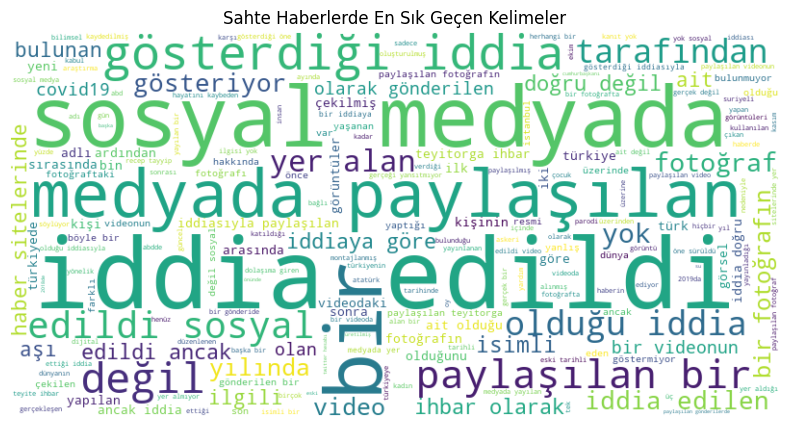

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Sahte haberlerin (status=0) en çok kullanılan kelimelerini görelim
fake_text = " ".join(df[df['status']==0]['temiz_metin'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Sahte Haberlerde En Sık Geçen Kelimeler')
plt.show()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# En sık geçen ikili kelime gruplarını (Bigram) bulalım
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

top_bigrams = get_top_ngram(df['temiz_metin'], n=2)
print("En Sık Geçen İkili Kelime Grupları (Bigrams):")
for word, freq in top_bigrams:
    print(f"{word}: {freq}")

En Sık Geçen İkili Kelime Grupları (Bigrams):
iddia edildi: 1063
sosyal medyada: 792
medyada paylaşılan: 472
gösterdiği iddia: 399
recep tayyip: 281
paylaşılan bir: 269
cumhurbaşkanı recep: 263
kahramanmaraş merkezli: 249
tayyip erdoğan: 215
olduğu iddia: 189


In [ ]:
import snowballstemmer

# Türkçe kök bulucu (stemmer) ayarlanıyor
stemmer = snowballstemmer.stemmer('turkish')

def kök_bul(text):
    words = str(text).split()
    return " ".join(stemmer.stemWords(words))

print("Kök bulma (Lematizasyon) işlemi başladı... Biraz sürebilir (Veri büyük).")
df['final_metin'] = df['temiz_metin'].apply(kök_bul)

# VE FİNAL: Arkadaşlarına teslim edeceğin altın değerindeki dosya
df.to_csv('temizlenmiş_veriseti.csv', index=False)
print("\n🔥 İŞLEM TAMAM! 'temizlenmiş_veriseti.csv' başarıyla oluşturuldu.")
print("Veri Madenciliği aşamaları eksiksiz mühürlendi.")

Kök bulma (Lematizasyon) işlemi başladı... Biraz sürebilir (Veri büyük).

🔥 İŞLEM TAMAM! 'temizlenmiş_veriseti.csv' başarıyla oluşturuldu.
Veri Madenciliği aşamaları eksiksiz mühürlendi.


In [6]:
# --- KALİTE KONTROL VE VERİ MADENCİLİĞİ KARŞILAŞTIRMA ---
# Bu kodun amacı; ham veri (description) ile tüm madencilik süreçlerinden 
# (temizlik, stopwords atma, lematizasyon) geçmiş son veriyi (final_metin) 
# yan yana getirip yapılan işlemin başarısını gözle muayene etmektir.

print("--- VERİ MADENCİLİĞİ ÖNCESİ VE SONRASI KARŞILAŞTIRMA ---")
# 'description' ham veriyi, 'final_metin' ise senin işlediğin tertemiz veriyi temsil eder.
print(df[['description', 'final_metin']].head(10))

# Not: Eğer çıktıda kelimelerin ekleri atılmış ve sadece kökleri kalmışsa 
# (Örn: 'geliyorlar' -> 'gel'), madencilik başarıyla mühürlenmiş demektir.

--- VERİ MADENCİLİĞİ ÖNCESİ VE SONRASI KARŞILAŞTIRMA ---
                                         description  \
0  Antalya merkezli 5 ilde gerçekleştirilen yasa ...   
1  Çevre, Şehircilik ve İklim Değişikliği Bakanı ...   
2  İddiaya göre Mithat Paşa, II. Abdülhamit’in ta...   
3  Cumhurbaşkanı Recep Tayyip Erdoğan, özel uçak ...   
4  Sosyal medyada bir Twitter kullanıcısı tarafın...   
5  Türkiye Büyük Millet Meclisi Başkanı Mustafa Ş...   
6  2021’de paylaşılan görsel gerçek yakıt fiyatla...   
7  Sosyal medyada paylaşılan A Haber'in 2018 yılı...   
8  teyit.org’a ihbar olarak gönderilen bir haberd...   
9  Sosyal medyada paylaşılan bir iletide, Hindist...   

                                         final_metin  
0  antalya merkezli 5 il gerçekleştirile yas dış ...  
1  çevre şehircilik ikl değişiklik baka murat kur...  
2  iddia gör mithat paş ii abdülhamit taht indiri...  
3  cumhurbaşka recep tayyip erdoğa özel uçak tcca...  
4  sosyal medya bir twitter kullanıcıs taraf new ..

     |████████████████████████████████| 294 kB 1.3 MB/s eta 0:00:01
You should consider upgrading via the '/Users/oguzhan/MetinMadenciligiProje/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


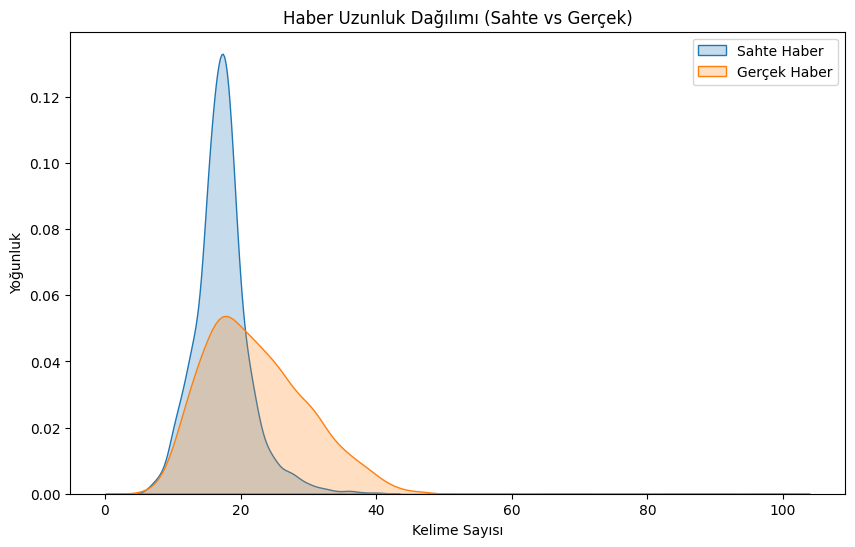

In [14]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Haberlerin kelime sayılarını hesaplayalım (İstatistiksel Veri Madenciliği)
df['kelime_sayisi'] = df['temiz_metin'].apply(lambda x: len(str(x).split()))

# 2. Grafik oluşturma
plt.figure(figsize=(10, 6))
# KDE (Yoğunluk) grafiği çiziyoruz
sns.kdeplot(df[df['status']==0]['kelime_sayisi'], label='Sahte Haber', fill=True)
sns.kdeplot(df[df['status']==1]['kelime_sayisi'], label='Gerçek Haber', fill=True)

plt.title('Haber Uzunluk Dağılımı (Sahte vs Gerçek)')
plt.xlabel('Kelime Sayısı')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()